## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [2]:
import pandas as pd

df = pd.read_csv("bank-additional-full.csv", sep=";")

In [3]:
df.shape

(41188, 21)

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
#select the numeric columns of the data set
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [ ]:
#Print (min, max, mean, std, skewness)
numeric_summary = numeric_df.agg(['min', 'max', 'mean', 'std', 'skew']).T
numeric_summary
#skewness scale: =0 for normal distribution, x>(+,-)1 highly skewed 
#positive skewness at x>+1, long right tail 

,min,max,mean,std,skew
age,17.000,98.000,40.024060,10.421250,0.784697
duration,0.000,4918.000,258.285010,259.279249,3.263141
campaign,1.000,56.000,2.567593,2.770014,4.762507
pdays,0.000,999.000,962.475454,186.910907,-4.922190
previous,0.000,7.000,0.172963,0.494901,3.832042
emp.var.rate,-3.400,1.400,0.081886,1.570960,-0.724096
cons.price.idx,92.201,94.767,93.575664,0.578840,-0.230888
cons.conf.idx,-50.800,-26.900,-40.502600,4.628198,0.303180
euribor3m,0.634,5.045,3.621291,1.734447,-0.709188
nr.employed,4963.600,5228.100,5167.035911,72.251528,-1.044262


In [9]:
categorical_df = df.select_dtypes(include=["object"])
categorical_df.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [10]:
for col in categorical_df.columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== job =====
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

===== marital =====
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

===== education =====
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

===== default =====
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

===== housing =====
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

===== loan =====
loan
no         33950
yes    

In [12]:
#df.isnull().sum()
df.isnull().sum().sum()
#no missing data 

0

In [17]:
#select categorical columns:
categorical_df = df.select_dtypes(include=["object"])
#count "unknown" per column:
for col in categorical_df.columns:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}")

job: 330
marital: 80
education: 1731
default: 8597
housing: 990
loan: 990


In [ ]:

#percentages of unkown data
unknown_percentages = {}

for col in categorical_df.columns:
    unknown_count = (df[col] == "unknown").sum()
    percentage = (unknown_count / len(df)) * 100
    unknown_percentages[col] = percentage

unknown_percentages

{'job': 0.8012042342429834,
 'marital': 0.1942313295134505,
 'education': 4.202680392347285,
 'default': 20.87258424783918,
 'housing': 2.40361270272895,
 'loan': 2.40361270272895,
 'contact': 0.0,
 'month': 0.0,
 'day_of_week': 0.0,
 'poutcome': 0.0,
 'y': 0.0}

In [ ]:
#investigating correlations
corr_matrix = numeric_df.corr()
corr_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


In [ ]:
#check for high correlated columns for |corr|>0.7
import numpy as np

threshold = 0.7
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):   # avoid duplicates and self-correlation
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 round(corr_value, 3))
            )

high_corr_pairs

[('cons.price.idx', 'emp.var.rate', 0.775),
 ('euribor3m', 'emp.var.rate', 0.972),
 ('nr.employed', 'emp.var.rate', 0.907),
 ('nr.employed', 'euribor3m', 0.945)]

In [23]:
#detect outliers:
numeric_df = df.select_dtypes(include=["int64", "float64"])

outlier_counts = {}

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = numeric_df[(numeric_df[col] < lower_bound) | 
                          (numeric_df[col] > upper_bound)]
    
    outlier_counts[col] = len(outliers)

outlier_counts

{'age': 469,
 'duration': 2963,
 'campaign': 2406,
 'pdays': 1515,
 'previous': 5625,
 'emp.var.rate': 0,
 'cons.price.idx': 0,
 'cons.conf.idx': 447,
 'euribor3m': 0,
 'nr.employed': 0}

In [ ]:
#outliers percentages
outlier_percentage = {
    col: (count / len(df)) * 100
    for col, count in outlier_counts.items()
}

outlier_percentage

{'age': 1.1386811692726035,
 'duration': 7.193842866854423,
 'campaign': 5.8415072351170245,
 'pdays': 3.6782558026609693,
 'previous': 13.65689035641449,
 'emp.var.rate': 0.0,
 'cons.price.idx': 0.0,
 'cons.conf.idx': 1.0852675536564047,
 'euribor3m': 0.0,
 'nr.employed': 0.0}

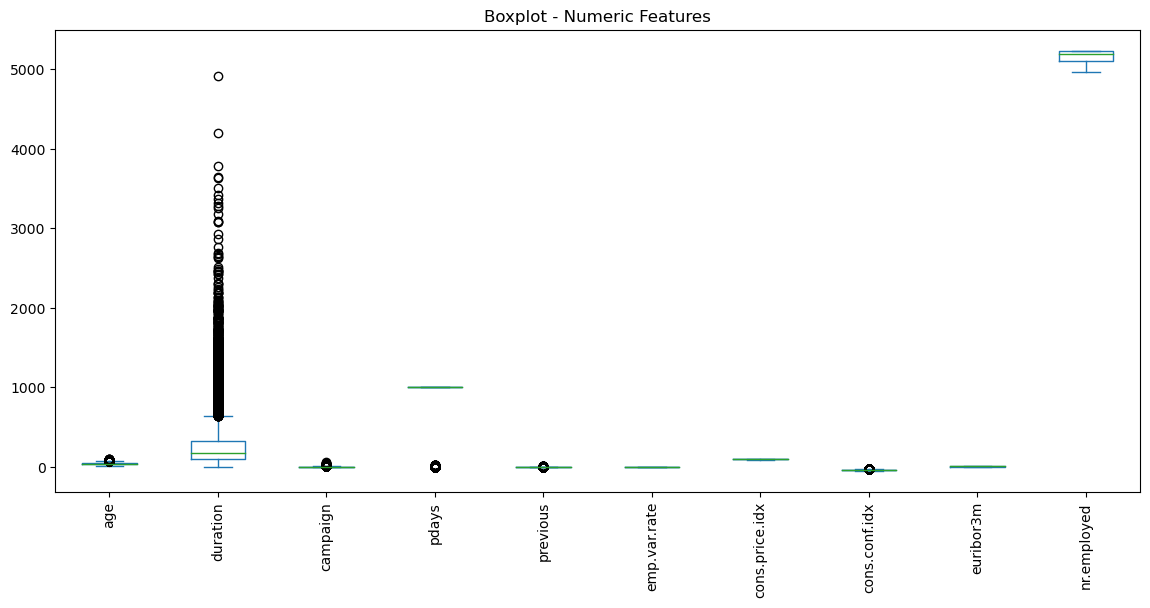

In [ ]:
#boxplot for outliers
import matplotlib.pyplot as plt

numeric_df.plot(kind="box", figsize=(14,6), rot=90)
plt.title("Boxplot - Numeric Features")
plt.show()

### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [39]:
#drop target y
df_clean = df.drop(columns=["y"])

In [40]:
#since emp.var.rate, euribor3m, nr.employed are highly correlated, I will drop emp.var.rate and nr.employed
df_clean = df_clean.drop(columns=["emp.var.rate", "nr.employed"])

In [41]:
import numpy as np
import pandas as pd

# encode anything that is NOT numeric (object/category/bool, etc.) into one hot encoding
non_numeric_cols = df_clean.select_dtypes(exclude=[np.number]).columns

df_encoded = pd.get_dummies(df_clean, columns=non_numeric_cols, drop_first=True)

# convert any remaining boolean columns to 0/1
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.dtypes.value_counts()

int32      43
int64       5
float64     3
Name: count, dtype: int64

In [42]:
#Scaling to ensure that every feature contributes equally to distance.:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_encoded)

In [43]:
df_encoded.isnull().sum().sum()
df_encoded.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('int32')], dtype=object)

### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [ ]:
from sklearn.cluster import KMeans

k = 3  # initial guess

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
#n_init: runs KMeans 10 times with different initial centroids and keeps the best (more stable).
#random_state: reproducible result

labels = kmeans.fit_predict(X) #compute the cluster centroids from the data (training)
#then assigns points to the nearest centroids
#no centroid update 

In [45]:
import pandas as pd
#Assign each data point to a cluster (store labels)
df_with_clusters = df_clean.copy()
df_with_clusters["cluster"] = labels

df_with_clusters["cluster"].value_counts().sort_index()

cluster
0    20485
1    19184
2     1519
Name: count, dtype: int64

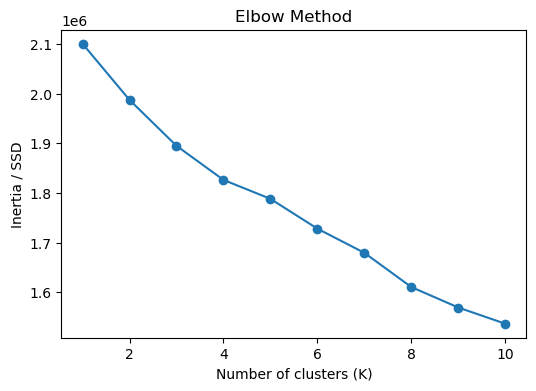

In [49]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Create an empty list to store the SSD (inertia) values for each K
ssd = []

# Define the range of cluster numbers we want to test (from 1 to 10)
K_range = range(1, 11)

# Loop over each possible number of clusters
for k in K_range:
    
    # Initialize the KMeans model with k clusters
    # n_clusters=k → number of centroids
    # n_init=10 → run the algorithm 10 times with different random initializations
    # random_state=42 → ensures reproducible results
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    
    # Fit the KMeans model to the scaled dataset X
    # This trains the model:
    #   1) Randomly initializes k centroids
    #   2) Assigns each point to nearest centroid
    #   3) Updates centroids as the mean of assigned points
    #   4) Repeats until convergence
    km.fit(X)
    
    # Store the inertia value for this k
    # inertia_ = total within-cluster Sum of Squared Distances (SSD)
    # Lower inertia means tighter clusters
    ssd.append(km.inertia_)
    
plt.figure(figsize=(6,4))
plt.plot(list(K_range), ssd, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia / SSD")
plt.title("Elbow Method")
plt.show()

In [ ]:
#I can't see an elbow point it is decreasing sharply
#However, two clusters might be better 

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

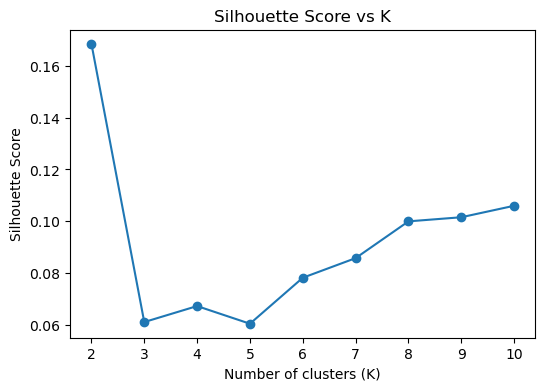

[0.16849323265800037,
 0.061145457589262535,
 0.0673143384420855,
 0.06050349163576129,
 0.07823060222769534,
 0.085801527710226,
 0.09998571439844563,
 0.10157012623121806,
 0.1059965526827733]

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Create an empty list to store silhouette scores for each value of K
sil_scores = []

# Define the range of cluster numbers to test (starting from 2)
# Silhouette score cannot be computed for K=1
K_range = range(2, 11)

# Loop over each possible number of clusters
for k in K_range:
    
    # Initialize the KMeans model with k clusters
    # n_clusters=k → number of centroids
    # n_init=10 → run algorithm 10 times with different initial centroid seeds
    # random_state=42 → ensures reproducibility
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    
    # Fit the model and assign each data point to its nearest centroid
    # fit_predict():
    #   1) Learns the centroids (fit)
    #   2) Returns cluster labels for each sample (predict)
    labels = kmeans.fit_predict(X)
    
    # Compute silhouette score for this clustering
    # silhouette_score measures how well-separated the clusters are:
    #   - close to 1 → well-separated clusters
    #   - close to 0 → overlapping clusters
    #   - negative → poor clustering
    score = silhouette_score(X, labels)
    
    # Store the silhouette score for this K
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

sil_scores